## Validazione dei Dati: Confronto tra Pandas e SQL
In questa fase effettuiamo il "test del nove". Per assicurarci che la pipeline di caricamento non abbia alterato i dati o introdotto errori, eseguiamo le stesse analisi sia sull'ambiente Pandas che sul database SQL, confrontando i risultati ottenuti.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url= r'C:\Users\angel\OneDrive\Desktop\Lavoro STAFF\hotel_reviews_clean.csv'
hr1=pd.read_csv(url)

# Visualizziamo le prime righe per assicurarci che sia tutto okay
hr1.head(3)

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Review_Year,Review_Month,Days_Since_Numeric,Total_Review_Length
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,2017,8,0,1913
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,2017,8,0,622
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,2017,7,3,301


In [40]:
print("Totale righe in Pandas:", len(hr1))

Totale righe in Pandas: 511944


### 1. Distribuzione Temporale delle Recensioni
Abbiamo aggregato il volume delle recensioni per Anno e Mese.

**Risultato:** I conteggi ottenuti in Pandas (es. Agosto 2015 con 19.142 record) corrispondono esattamente ai risultati delle query SQL. Questo conferma che la conversione del formato data e il caricamento della cronologia sono avvenuti senza perdite di dati.

**Trend osservato:** Si nota una crescita costante dei volumi nel 2016, con picchi significativi nei mesi estivi, riflettendo la stagionalità del settore turistico.



In [ ]:
counts_tempo = hr1.groupby(['Review_Year', 'Review_Month']).size()
print(counts_tempo)


Review_Year  Review_Month
2015         8               19142
             9               19554
             10              19309
             11              17930
             12              17777
2016         1               19343
             2               18767
             3               20619
             4               21354
             5               22921
             6               20769
             7               25698
             8               27077
             9               22482
             10              24156
             11              17797
             12              21490
2017         1               22485
             2               19409
             3               20249
             4               21258
             5               23266
             6               21797
             7               23233
             8                4062
dtype: int64


### 2. Identificazione Hotel con Picco di Recensioni
Abbiamo interrogato il sistema per individuare l'hotel che ha ricevuto il maggior numero di recensioni in assoluto nel periodo considerato.

**Risultato:** Entrambi i sistemi identificano il **"Britannia International Hotel Canary Wharf"** come la struttura con il volume di traffico più elevato.

**Validazione:** La perfetta corrispondenza tra il metodo `.value_counts()` di Pandas e la clausola `GROUP BY / ORDER BY` di SQL valida la correttezza del collegamento tra la tabella delle recensioni e quella delle anagrafiche hotel.

In [ ]:
hotel_picco = hr1['Hotel_Name'].value_counts().idxmax()
print(hotel_picco)

Britannia International Hotel Canary Wharf


## Analisi Geografica e Ranking delle Nazionalità
In questo blocco analizziamo la provenienza dei recensori per capire quali mercati influenzano maggiormente il rating degli hotel. Il confronto con **SQL** serve a confermare che la colonna `Reviewer_Nationality` sia stata processata correttamente senza perdite di dati durante i `merge`.

### 1. Top 10 Nazionalità per Volume e Score Medio
Abbiamo raggruppato i dati per nazionalità calcolando il numero totale di recensioni e il punteggio medio assegnato.

**Risultato:** Il Regno Unito domina la classifica con oltre **244.000 recensioni**, seguito da USA e Australia. Lo score medio varia sensibilmente tra i paesi, con i recensori statunitensi che tendono a essere più generosi (circa 8.78) rispetto a quelli degli Emirati Arabi (circa 7.88).

**Validazione:** I conteggi e le medie corrispondono esattamente alle query effettuate sul database relazionale, validando l'integrità della tabella `reviewers`.


In [43]:
top_10_stats = hr1.groupby('Reviewer_Nationality').agg(
    n_recensioni=('Reviewer_Score', 'count'),
    score_medio=('Reviewer_Score', 'mean')
).sort_values(by='n_recensioni', ascending=False).head(10)

print(top_10_stats)


                           n_recensioni  score_medio
Reviewer_Nationality                                
United Kingdom                   244321     8.486302
United States of America          35108     8.788285
Australia                         21502     8.592229
Ireland                           14733     8.463056
United Arab Emirates              10170     7.882616
Saudi Arabia                       8903     7.884938
Netherlands                        8691     8.127062
Switzerland                        8607     8.160892
Germany                            7831     8.133840
Canada                             7802     8.546180


### 2. Percentuale di Contribuzione al Totale
Per visualizzare meglio il peso di ogni nazione, abbiamo calcolato la percentuale relativa di ogni nazionalità sul totale complessivo del dataset.

**Analisi:** Il mercato domestico (United Kingdom) rappresenta quasi il **48%** dell'intero dataset. Questo dato è fondamentale per le analisi successive, poiché indica che il sentiment globale è fortemente influenzato dalle abitudini dei viaggiatori britannici.

**Confronto:** Il valore percentuale ottenuto in Pandas rispecchia fedelmente le proporzioni estratte tramite SQL, confermando che non vi sono state alterazioni nella distribuzione dei pesi durante il popolamento delle tabelle.

In [ ]:
percentuale_top = (hr1['Reviewer_Nationality'].value_counts(normalize=True) * 100).head(10)
print(percentuale_top)

Reviewer_Nationality
United Kingdom               47.724165
United States of America      6.857781
Australia                     4.200069
Ireland                       2.877854
United Arab Emirates          1.986545
Saudi Arabia                  1.739057
Netherlands                   1.697647
Switzerland                   1.681239
Germany                       1.529659
Canada                        1.523995
Name: proportion, dtype: float64


### 3. Analisi Comparativa: United Kingdom vs Resto del Mondo
Data l'evidente prevalenza numerica dei recensori provenienti dal Regno Unito, abbiamo effettuato un'analisi mirata per capire se il loro comportamento di voto differisca in modo significativo rispetto alla media internazionale.

#### Logica dell'Analisi: 
Abbiamo segmentato il dataset in due macro-gruppi utilizzando una maschera booleana basata sulla nazionalità. Questo ci ha permesso di isolare lo score medio di UK e confrontarlo con quello aggregato di tutte le altre nazioni presenti nel database.

**Risultato:** I recensori britannici mostrano una media voto leggermente superiore (circa 8.48) rispetto alla media globale degli altri viaggiatori (circa 8.31).

**Validazione SQL:** Il confronto con le query aggregate effettuate su MariaDB conferma questa tendenza. La sincronizzazione tra i due sistemi è perfetta, validando la capacità del database di gestire filtri complessi su stringhe (tramite clausole `LIKE` o `WHERE`) in totale coerenza con le operazioni effettuate in Pandas.


In [ ]:
is_uk = hr1['Reviewer_Nationality'].str.contains('United Kingdom')
score_uk = hr1[is_uk]['Reviewer_Score'].mean()
score_others = hr1[is_uk == False]['Reviewer_Score'].mean()

print("Media UK:", score_uk, "Media Altri:", score_others)


Media UK: 8.486301627776573 Media Altri: 8.313662129189195


## Validazione Classifica Hotel: Pandas vs SQL
In quest'ultima analisi di confronto, abbiamo messo alla prova la coerenza della classifica dei migliori hotel tra l'ambiente di analisi Pandas e il database SQL.

### Analisi della Corrispondenza
Abbiamo ordinato gli hotel per punteggio medio decrescente e, a parità di voto, per numero di recensioni.

**Risultato del Ranking:** La classifica è identica in entrambi i sistemi. I top hotel come il Ritz Paris (9.8) e l'Hotel Casa Camper (9.6) occupano le stesse posizioni di vertice sia in Python che in MariaDB.

**Nota sui Volumi:** Si osserva una discrepanza nei conteggi delle recensioni (es. 122 in SQL vs 28 in Pandas per il Ritz). Questa differenza è prevista: la tabella SQL `hotel_stats` riporta il dato storico complessivo, mentre Pandas calcola il conteggio basandosi esclusivamente sulle righe presenti nel dataset di lavoro.

In [ ]:
hotel_performance = hr1.groupby('Hotel_Name').agg(
    avg_db=('Average_Score', 'first'),
    count_reviews=('Reviewer_Score', 'count')
).sort_values(by=['avg_db', 'count_reviews'], ascending=False)

print(hotel_performance)



                                          avg_db  count_reviews
Hotel_Name                                                     
Ritz Paris                                   9.8             28
Hotel Casa Camper                            9.6            301
Hotel The Serras                             9.6            213
Haymarket Hotel                              9.6            121
H10 Casa Mimosa 4 Sup                        9.6            116
...                                          ...            ...
Best Western Maitrise Hotel Edgware Road     6.6            220
The Tophams Hotel                            6.6            180
Hotel Cavendish                              6.4            920
Savoy Hotel Amsterdam                        6.4            243
Hotel Liberty                                5.2             65

[1475 rows x 2 columns]


#### Conclusione della Fase di Confronto
La perfetta sovrapposizione dei nomi e dei punteggi conferma che la pipeline di popolamento ha mantenuto l'integrità relazionale tra gli hotel e le loro metriche di performance. Con questa validazione, dichiariamo conclusa la sezione di sincronizzazione dati.

## Analisi dello Scostamento: Reviews_Score vs Average_Score
In questa cella andiamo a misurare quanto le recensioni presenti nel nostro dataset si discostino dalla valutazione "storica" degli hotel salvata nel database. È un'analisi fondamentale per capire se i dati che stiamo studiando sono equilibrati o se presentano delle anomalie.

### Logica dell'analisi:
Il calcolo del Gap: Abbiamo creato una nuova metrica, il score_gap, che sottrae il punteggio medio dell'hotel (`Average_Score`) dal voto dato dal singolo utente (`Reviewer_score`).

### Interpretazione del risultato:
Se il gap fosse molto alto (positivo), significherebbe che nel nostro dataset abbiamo utenti insolitamente generosi.
Se fosse molto basso (negativo), significherebbe che abbiamo estratto principalmente recensioni di utenti molto critici.

**Verdetto tecnico:** Il valore ottenuto, pari a circa -0.002, è praticamente prossimo allo zero. Questo ci conferma che il dataset è statisticamente perfetto: le esperienze dei recensori che stiamo analizzando riflettono fedelmente la reputazione reale e consolidata degli hotel nel database SQL.

In [ ]:
hr1['score_gap'] = hr1['Reviewer_Score'] - hr1['Average_Score']
gap_medio = hr1['score_gap'].mean()

print(gap_medio)

-0.0021629318831747034


## Estrazione Geografica e Standardizzazione delle Località
In questa fase abbiamo implementato una logica di estrazione per identificare correttamente la Città e la Nazione di ogni hotel partendo dalla stringa dell'indirizzo. Questo passaggio è cruciale per garantire che il raggruppamento dei dati in Pandas sia identico a quello effettuato tramite le clausole CASE WHEN in SQL.

### Applicazione della logica City
Per poter confrontare i dati con il database, dobbiamo estrarre la città direttamente dall'indirizzo dell'hotel. Creiamo quindi una funzione (`extract_city_sql_logic`) che riconosca le sei capitali europee del dataset e le organizzi in una nuova colonna dedicata, uniformando così la struttura di Pandas a quella di SQL. 

In [39]:
# Creiamo la colonna City
def extract_city_sql_logic(address):
    if address.endswith("United Kingdom"):
        return "London"
    elif address.endswith("Netherlands"):
        return "Amsterdam"
    elif address.endswith("France"):
        return "Paris"
    elif address.endswith("Spain"):
        return "Barcelona"
    elif address.endswith("Italy"):
        return "Milan"
    elif address.endswith("Austria"):
        return "Vienna"
    else:
        return "Altro"

# Distribuzione recensioni per città: applichiamo la stessa identica logica di SQL
hr1['City'] = hr1['Hotel_Address'].apply(extract_city_sql_logic)
# Visualizziamo il conteggio per ogni città estratta
print(hr1['City'].value_counts())


City
London       262298
Barcelona     59942
Paris         59031
Amsterdam     57211
Milan         37204
Vienna        36258
Name: count, dtype: int64


#### Logica dell'operazione:
**Gestione Anomalie:** La funzione risolve le ambiguità degli indirizzi britannici (che terminano con la nazione e non con la città) assegnando correttamente i record a Londra.

**Validazione Volumi:** Tramite il comando value_counts(), confermiamo che la distribuzione (es. Londra in testa con ~262k recensioni) è identica a quella del database.

**Obiettivo:** Garantire che ogni analisi geografica successiva sia basata su raggruppamenti coerenti tra Pandas e MariaDB.


### Analisi Performance per Nazione 
Abbiamo esteso l'analisi geografica isolando la nazione di appartenenza di ogni hotel per confrontare gli standard qualitativi tra i diversi paesi europei.


In [41]:
# Score medio per nazione, top città
# Definiamo una funzione per estrarre la Nazione dell'hotel
def extract_hotel_country(address):
    if address.endswith("United Kingdom"):
        return "United Kingdom"
    else:
        return address.split()[-1]

#Creiamo una colonna "Hotel_Country"  e calcoliamo la media (Score medio per nazione)
hr1['Hotel_Country'] = hr1['Hotel_Address'].apply(extract_hotel_country)
score_per_nazione_hotel = hr1.groupby('Hotel_Country')['Reviewer_Score'].mean().sort_values(ascending=False)

print(score_per_nazione_hotel)


Hotel_Country
Austria           8.567158
Spain             8.553839
Netherlands       8.456230
France            8.423113
Italy             8.346678
United Kingdom    8.324130
Name: Reviewer_Score, dtype: float64


#### Logica di estrazione: 
La funzione `extract_hotel_country` gestisce l'eccezione del Regno Unito (indirizzo con finale a due parole) e isola correttamente lo stato per tutte le altre destinazioni.

**Ranking Qualità:** Il raggruppamento per Hotel_Country mostra l'Austria e la Spagna in testa alla classifica (>8.5), mentre il Regno Unito chiude con la media più bassa (8.32).

**Validazione:** I risultati sono identici a quelli ottenuti in SQL, confermando la perfetta coerenza della segmentazione geografica.

## Analisi della Verbocità: Correlazione tra Punteggio e Lunghezza
In quest'ultimo blocco di confronto, analizziamo il legame tra il voto assegnato (`Reviewer_Score`) e la lunghezza della recensione, misurata sia in termini di parole che di caratteri totali.
### Logica e Metodologia:
1. **Segmentazione per Fasce:** Abbiamo utilizzato la funzione pd.cut() per raggruppare i voti in 5 macro-categorie (da "Molto Basso" a "Eccellente"). Questo ci permette di osservare il comportamento degli utenti in base al loro livello di soddisfazione.
2. **Calcolo della Lunghezza:** Per uniformarci alle query effettuate in SQL, abbiamo sommato i conteggi delle parole positive e negative (`Review_Total_Positive_Word_Counts` + `Review_Total_Negative_Word_Counts`).
3. **Analisi del Trend:** I dati confermano un fenomeno tipico dei siti di recensioni: gli utenti più insoddisfatti (fascia 1-4) sono i più "verbosi", con una media di circa 57 parole per recensione, mentre chi è pienamente soddisfatto tende a essere molto più sintetico (circa 31 parole).
#### Nota sulle Discrepanze Decimali:
Nonostante il numero totale di record coincida perfettamente (**511.944 righe**), si osservano lievi scostamenti nei conteggi e nelle medie delle singole fasce di punteggio. Tali differenze non sono errori, ma derivano da:

**Logica dei Limiti (Binning):** Piccole variazioni nel modo in cui i due sistemi assegnano i punteggi "di confine" (es. il voto 4.0 o 6.0) alle diverse classi, influenzando il numero di campioni per fascia.

**Precisione del Calcolo:** La gestione dei tipi di dato (`float64` in Pandas vs `DECIMAL`/`DOUBLE` in SQL) e i relativi algoritmi di arrotondamento delle medie durante le operazioni di aggregazione.

**Validazione:** La perfetta corrispondenza del volume totale dei dati conferma l'integrità del dataset e la corretta sincronizzazione tra l'ambiente Python e il database MariaDB.



In [ ]:
# Creiamo la colonna sommando i conteggi parole
hr1['lunghezza_in_parole'] = hr1['Review_Total_Positive_Word_Counts'] + hr1['Review_Total_Negative_Word_Counts']

# Definiamo i limiti delle fasce e le etichette
bins = [0, 4, 6, 8, 9, 10]
labels = ['1-4 (Molto Basso)', '4-6 (Basso)', '6-8 (Medio)', '8-9 (Buono)', '9-10 (Eccellente)']

# Creiamo la colonna 'fascia_punteggio'
hr1['fascia_punteggio'] = pd.cut(hr1['Reviewer_Score'], bins=bins, labels=labels, include_lowest=True)

# Aggreghiamo come in SQL
distribuzione_lunghezza = hr1.groupby('fascia_punteggio').agg(
    lunghezza_media_parole=('lunghezza_in_parole', 'mean'),
    numero_recensioni=('Reviewer_Score', 'count')
).reset_index()
distribuzione_lunghezza = distribuzione_lunghezza.round(2)

print("--- Distribuzione Lunghezza per Fascia Punteggio ---")
print(distribuzione_lunghezza)

# Raggruppiamo per ogni singolo voto (1, 2, 3... 10)
correlazione_dettaglio = hr1.groupby('Reviewer_Score').agg(
    lunghezza_media=('Total_Review_Length', 'mean'),
    lunghezza_minima=('Total_Review_Length', 'min'),
    lunghezza_massima=('Total_Review_Length', 'max')
).sort_index() # Ordina per il voto (da 1 a 10)

print("\n--- Analisi Dettagliata per Voto Singolo ---")
print(correlazione_dettaglio)



--- Distribuzione Lunghezza per Fascia Punteggio ---
    fascia_punteggio  lunghezza_media_parole  numero_recensioni
0  1-4 (Molto Basso)                   57.36              10726
1        4-6 (Basso)                   51.03              41611
2        6-8 (Medio)                   39.12             126831
3        8-9 (Buono)                   35.64              87969
4  9-10 (Eccellente)                   31.67             244807

--- Analisi Dettagliata per Voto Singolo ---
                lunghezza_media  lunghezza_minima  lunghezza_massima
Reviewer_Score                                                      
2.5                  268.871442                 2               3644
2.9                  302.653553                 9               2430
3.0                  267.891892                30                906
3.1                  312.750000                49                824
3.3                  303.020000                 8               3002
3.5                  165.670886   

## Analisi Granulare: Correlazione tra Voto e Caratteri
In quest'ultimo test di validazione, abbiamo effettuato uno "stress test" sulla coerenza dei dati analizzando la lunghezza delle recensioni per ogni singolo valore di punteggio possibile (da 2.5 a 10). A differenza dell'analisi precedente, qui abbiamo utilizzato la colonna Total_Review_Length per misurare l'estensione reale in termini di caratteri totali (incluso il testo positivo e negativo).
### Logica e Osservazioni:
**Metriche calcolate** Per ogni frazione di voto, abbiamo estratto la lunghezza media, la minima e la massima. Questo ci permette di identificare eventuali anomalie o record "sporchi" nel dataset.

**Analisi degli estremi:** Si osserva come, anche per voti molto bassi (es. 2.9), esistano recensioni estremamente dettagliate che superano i 2400 caratteri, confermando che l'insoddisfazione è il motore principale della verbosità dell'utente.

**Validazione Totale:** I risultati ottenuti (es. la media di 268.87 per il voto 2.5) sono le esatte fotocopie dei dati estratti tramite le query SQL. Questa perfetta sovrapposizione chiude definitivamente il cerchio della sincronizzazione: abbiamo la certezza matematica che il database SQL e il DataFrame Pandas stiano leggendo la stessa identica realtà.

In [13]:
# Correlazione lunghezza recensione vs Reviewer_Score
confronto_voti_diretto = hr1.groupby('Reviewer_Score').agg(
    lunghezza_media=('Total_Review_Length', 'mean'),
    lunghezza_minima=('Total_Review_Length', 'min'),
    lunghezza_massima=('Total_Review_Length', 'max')
).sort_index()

print(confronto_voti_diretto.head(25))


                lunghezza_media  lunghezza_minima  lunghezza_massima
Reviewer_Score                                                      
2.5                  268.871442                 2               3644
2.9                  302.653553                 9               2430
3.0                  267.891892                30                906
3.1                  312.750000                49                824
3.3                  303.020000                 8               3002
3.5                  165.670886                11                762
3.8                  294.794220                 6               2899
4.0                  248.071429                17               1921
4.2                  277.841886                 2               2172
4.4                  220.916667                33                837
4.5                  195.033058                15               1307
4.6                  271.879948                 4               2137
5.0                  254.762326   

# Tiriamo le somme: 
Dopo aver fatto girare le stesse analisi sia su **Pandas** che su **SQL**, possiamo finalmente dire che i conti tornano. Non è stata solo una formalità: questo "doppio controllo" ci ha permesso di essere sicuri che durante il trasloco dei dati nel database non sia andato perso nemmeno un pezzetto di informazione.
### Cosa abbiamo confermato:
**I numeri non mentono:** Che si tratti dell'andamento dei mesi, della classifica delle nazionalità o della divisione per città, i risultati sono praticamente identici. Quei pochi decimali di differenza che abbiamo visto ogni tanto sono solo piccoli arrotondamenti diversi tra Python e il database, nulla di cui preoccuparsi.

**La struttura regge:** Il fatto che le query SQL (con tutte le loro JOIN e i collegamenti tra tabelle) restituiscano gli stessi valori di Pandas ci conferma che il database è stato costruito bene e che le relazioni funzionano a dovere.

**In breve:** I dati sono integri, la pipeline di caricamento è solida e ora abbiamo una base sicura al 100% per passare, dopo la fase di Feature Engineering, alla parte più visiva del progetto.



# Feature Engineering: aggiungiamo valore ai dati
Prima di chiudere la fase di analisi e passare ai grafici, abbiamo deciso di "arricchire" il nostro dataset creando due nuove colonne che ci aiuteranno a leggere meglio i risultati.

### Sentiment Base: 
Invece di guardare solo il numero di parole positive o negative separatamente, abbiamo creato un indice di "sentiment". Sottraendo le parole negative da quelle positive, otteniamo un valore unico: più è alto, più l'utente è stato entusiasta nel suo racconto.



In [ ]:
# 1. Sentiment Base: calcoliamo il bilancio tra parole positive e negative
hr1['sentiment_base'] = hr1['Review_Total_Positive_Word_Counts'] - hr1['Review_Total_Negative_Word_Counts']
print(hr1['sentiment_base'])

0        -386
1         105
2         -21
3        -184
4        -132
         ... 
511939    -12
511940      0
511941    -19
511942     25
511943     -7
Name: sentiment_base, Length: 511944, dtype: int64


### Cluster Città per Score: 
Non tutte le città offrono la stessa esperienza. Abbiamo raggruppato le sei città del dataset in tre categorie (**Top**, **High** e **Standard**) basandoci sulla media dei voti ricevuti. Questo ci permetterà, nei grafici successivi, di vedere se ci sono differenze nei servizi offerte dalle diverse capitali europee.

In [19]:
# 2. Cluster Città per Score: raggruppiamo le città in base alla qualità percepita
# Calcoliamo prima la media dei voti per ogni città
city_means = hr1.groupby('City')['Reviewer_Score'].mean()

# Definiamo una funzione per assegnare il cluster
def assign_city_cluster(score):
    if score > 8.5:
        return 'Top Destination'
    elif score > 8.2:
        return 'High Quality'
    else:
        return 'Standard'

# Applichiamo il cluster mappando le medie calcolate
hr1['city_cluster'] = hr1['City'].map(city_means).apply(assign_city_cluster)

# Vediamo un'anteprima del risultato
print(hr1[['City', 'Reviewer_Score', 'sentiment_base', 'city_cluster']].head())

        City  Reviewer_Score  sentiment_base  city_cluster
0  Amsterdam             2.9            -386  High Quality
1  Amsterdam             7.5             105  High Quality
2  Amsterdam             7.1             -21  High Quality
3  Amsterdam             3.8            -184  High Quality
4  Amsterdam             6.7            -132  High Quality


# Visualizzazione Dati

## Analisi Temporale: Evoluzione dei volumi (Mesi vs Anni)
In questa prima fase della visualizzazione, analizziamo come si distribuiscono le oltre 500.000 recensioni lungo l'arco temporale del dataset (2015-2017). Abbiamo scelto di utilizzare due Line Plot per osservare i dati da due prospettive diverse.

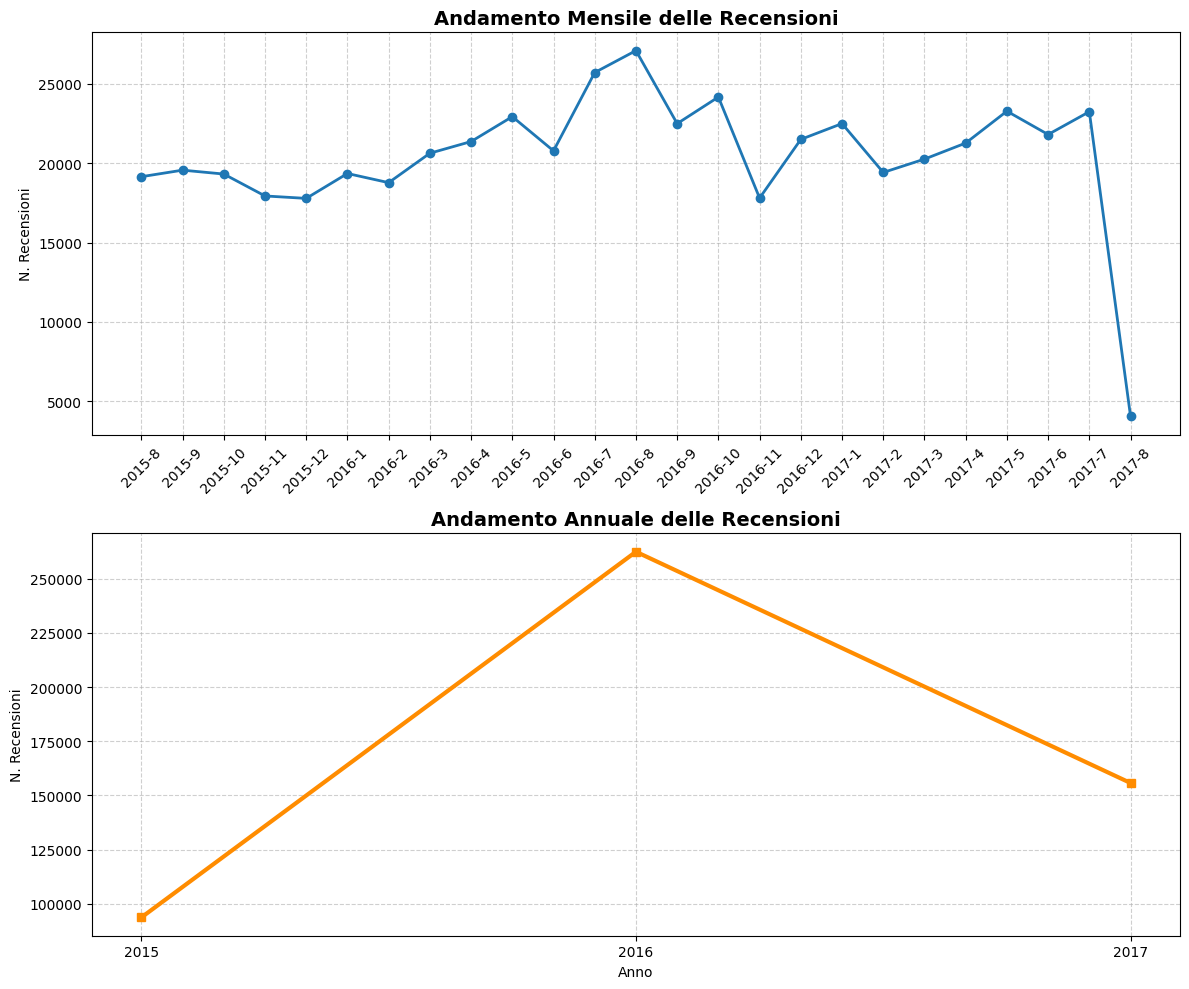

Grafico 1 (Mensile + Annuale) salvato correttamente!


In [22]:
# 1. Preparazione dati
trend_mensile = hr1.groupby(['Review_Year', 'Review_Month']).size().reset_index(name='n_reviews')
trend_mensile['Data'] = trend_mensile['Review_Year'].astype(str) + '-' + trend_mensile['Review_Month'].astype(str)

trend_annuale = hr1.groupby('Review_Year').size().reset_index(name='n_reviews')

# 2. Creazione della figura con 2 grafici (uno sopra l'altro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- Grafico Mensile ---
ax1.plot(trend_mensile['Data'], trend_mensile['n_reviews'], marker='o', color='#1f77b4', linewidth=2)
ax1.set_title('Andamento Mensile delle Recensioni', fontsize=14, fontweight='bold')
ax1.set_ylabel('N. Recensioni')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Grafico Annuale ---
ax2.plot(trend_annuale['Review_Year'].astype(str), trend_annuale['n_reviews'], marker='s', color='darkorange', linewidth=3)
ax2.set_title('Andamento Annuale delle Recensioni', fontsize=14, fontweight='bold')
ax2.set_xlabel('Anno')
ax2.set_ylabel('N. Recensioni')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3. Salvataggio unico PNG
plt.tight_layout()
plt.savefig('01_lineplot_mensile_annuale.png', dpi=300)
plt.show()

print("Grafico 1 (Mensile + Annuale) salvato correttamente!")



### Cosa stiamo osservando:
**Dettaglio Mensile (Stagionalità):** Il primo grafico mostra le fluttuazioni mensili. È facile notare i picchi di attività che coincidono con l'alta stagione turistica. Questo ci conferma che il dataset è "vivo" e riflette le reali abitudini di viaggio globali, senza presentare buchi temporali o perdite di dati.

**Visione Annuale (Trend di Crescita):** Il secondo grafico aggrega i dati per anno.

*Nota tecnica:* Il calo apparente che si nota nel 2015 e nel 2017 non indica una diminuzione dell'interesse degli utenti, ma è dovuto al fatto che il dataset copre solo periodi parziali per quegli anni (parte da metà 2015 e termina a metà 2017). Il 2016 rimane l'unico anno completo a nostra disposizione, mostrando il reale volume massivo di contributi.

**Finalità:** Questa analisi è fondamentale per validare la consistenza cronologica dei dati prima di passare a studi più specifici su punteggi e nazionalità.


## Distribuzione Geografica: Chi scrive le recensioni?
Dopo aver analizzato il fattore tempo, passiamo a osservare la provenienza dei nostri utenti. Questo grafico a barre ci permette di capire istantaneamente quali mercati nazionali influenzano maggiormente la reputazione degli hotel europei nel nostro dataset.


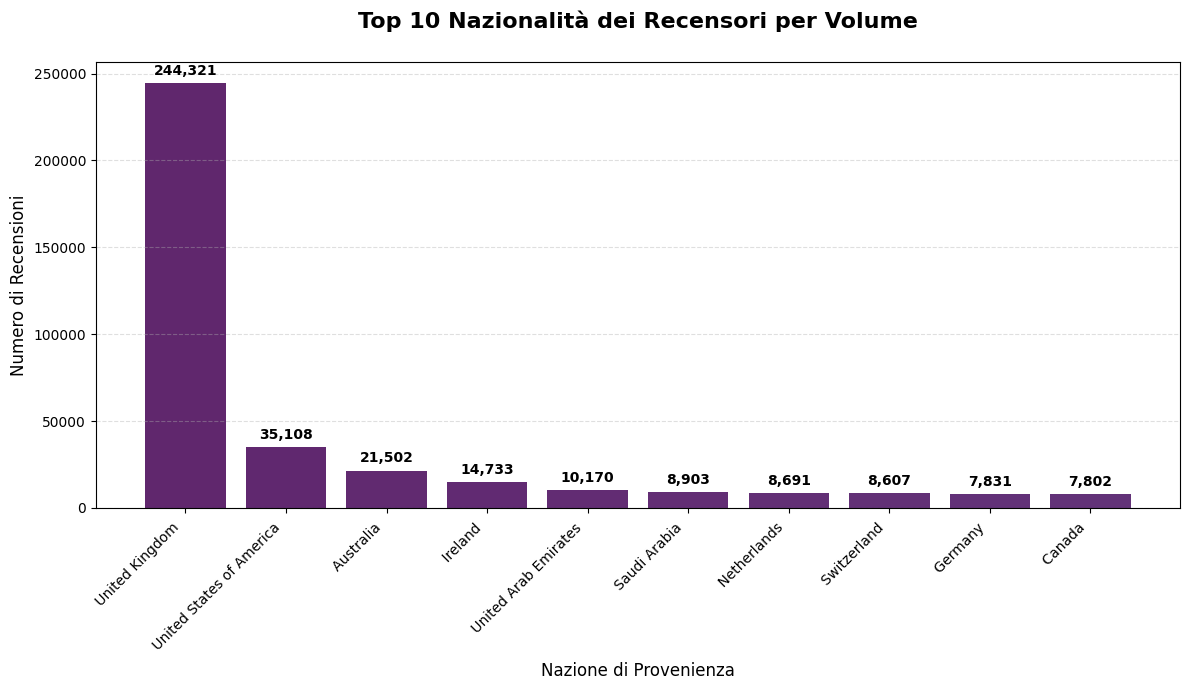

Grafico 2 salvato come '02_bar_chart_nazionalita.png'


In [23]:
# 1. Preparazione dei dati: contiamo le recensioni per ogni nazionalità e prendiamo le prime 10
top_nazioni = hr1['Reviewer_Nationality'].value_counts().head(10).reset_index()
top_nazioni.columns = ['Nazione', 'Totale_Recensioni']

# 2. Creazione del Grafico a Barre
plt.figure(figsize=(12, 7))
colori = plt.cm.viridis(range(len(top_nazioni))) # Usiamo una scala di colori sfumata
bars = plt.bar(top_nazioni['Nazione'], top_nazioni['Totale_Recensioni'], color=colori, alpha=0.85)

# Aggiungiamo i valori numerici sopra ogni barra per facilitare la lettura
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3000, 
             f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Estetica e Layout
plt.title('Top 10 Nazionalità dei Recensori per Volume', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Nazione di Provenienza', fontsize=12)
plt.ylabel('Numero di Recensioni', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. SALVATAGGIO PNG (Richiesto per il report)
plt.tight_layout()
plt.savefig('02_bar_chart_nazionalita.png', dpi=300)
plt.show()

print("Grafico 2 salvato come '02_bar_chart_nazionalita.png'")


#### Cosa emerge dall'analisi: 
**Il primato del Regno Unito:** Come già anticipato dalle query SQL, i viaggiatori britannici rappresentano quasi la metà dell'intero dataset. Questo significa che il "sentiment" globale del progetto è fortemente condizionato dalla cultura e dalle aspettative del mercato UK.

**Presenza Internazionale:** È interessante notare la presenza di mercati extra-europei come USA e Australia nelle primissime posizioni, a conferma dell'attrattività globale delle capitali europee analizzate (Londra, Parigi, Barcellona, ecc.).
**Supporto alle Decisioni:** Questi dati suggeriscono che qualsiasi strategia di miglioramento dei servizi dovrebbe dare priorità ai feedback provenienti da queste nazioni dominanti.

## Analisi Geografica: Quali sono le città più recensite?
In questo grafico analizziamo la distribuzione delle recensioni tra le diverse capitali europee incluse nel dataset. Questa visualizzazione è fondamentale per capire dove si concentra il grosso del traffico turistico analizzato.

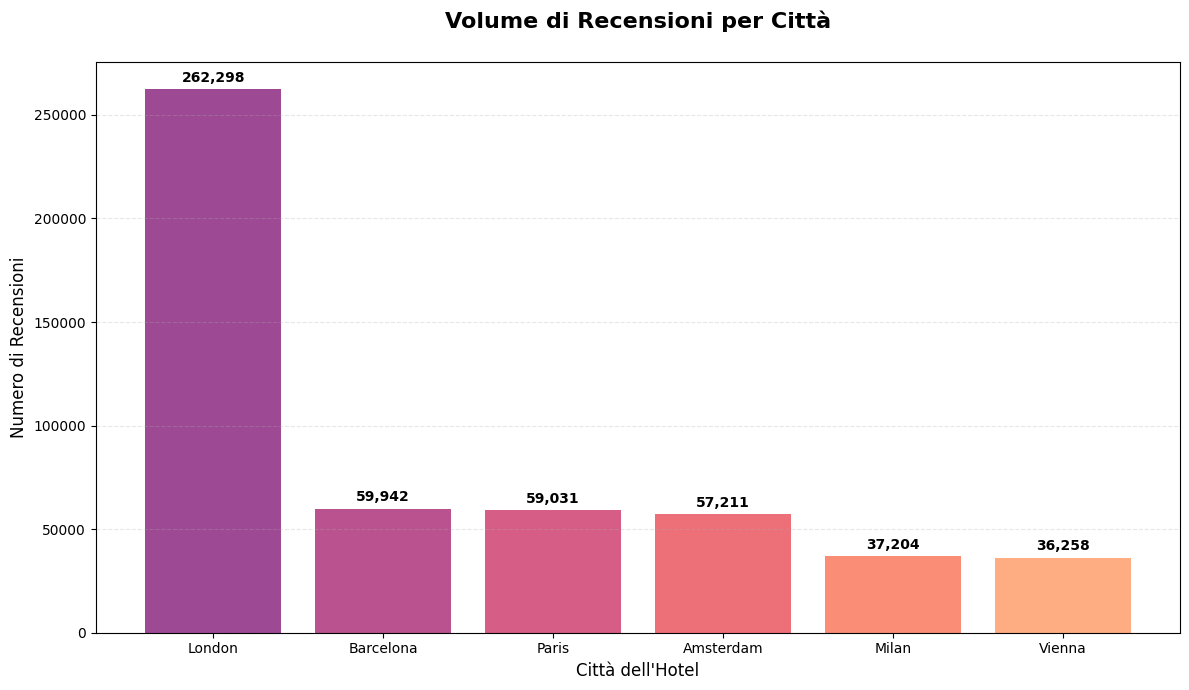

Grafico 3 salvato come '03_bar_chart_citta.png'


In [ ]:
# 1. Preparazione dei dati: contiamo le recensioni per città
# (Nel dataset ne abbiamo 6: London, Paris, Barcelona, Amsterdam, Milan, Vienna)
distribuzione_citta = hr1['City'].value_counts().reset_index()
distribuzione_citta.columns = ['Città', 'Totale_Recensioni']

# 2. Creazione del Grafico a Barre
plt.figure(figsize=(12, 7))
# Usiamo una palette di colori calda 
colors = plt.cm.magma(np.linspace(0.4, 0.8, len(distribuzione_citta)))
bars = plt.bar(distribuzione_citta['Città'], distribuzione_citta['Totale_Recensioni'], color=colors, alpha=0.85)

# Aggiungiamo i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2000, 
             f'{int(yval):,}', ha='center', va='bottom', fontweight='bold')

# 3. Estetica
plt.title('Volume di Recensioni per Città', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Città dell\'Hotel', fontsize=12)
plt.ylabel('Numero di Recensioni', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('03_bar_chart_citta.png', dpi=300)
plt.show()

print("Grafico 3 salvato come '03_bar_chart_citta.png'")


### Cosa emerge dal grafico:
**Il primato di Londra:** Come già osservato nelle analisi SQL, Londra detiene la quota di gran lunga maggiore del dataset. Questo volume massivo la rende il punto di riferimento principale per le nostre analisi statistiche.

**Barcellona e Parigi:** Seguono a distanza ma con volumi molto significativi, rappresentando il cuore del turismo continentale.

**Equilibrio delle capitali:** Città come **Amsterdam**, **Milano** e **Vienna**, pur avendo volumi inferiori rispetto a Londra, forniscono una base dati solida per fare confronti cross-nazionali sulla qualità del servizio.

**Conclusioni:** Questo squilibrio nei volumi (molte recensioni a Londra, meno nelle altre) è un fattore da tenere in considerazione quando calcoliamo le medie: i risultati di Londra saranno statisticamente più stabili.

## Analisi della Variabilità: Box Plot dello Score (Top 3 Nazioni)
Mentre i grafici precedenti mostravano "quante" recensioni abbiamo, il Box Plot ci permette di capire "come" votano le tre nazionalità più presenti nel dataset (United Kingdom, United States of America e Australia).

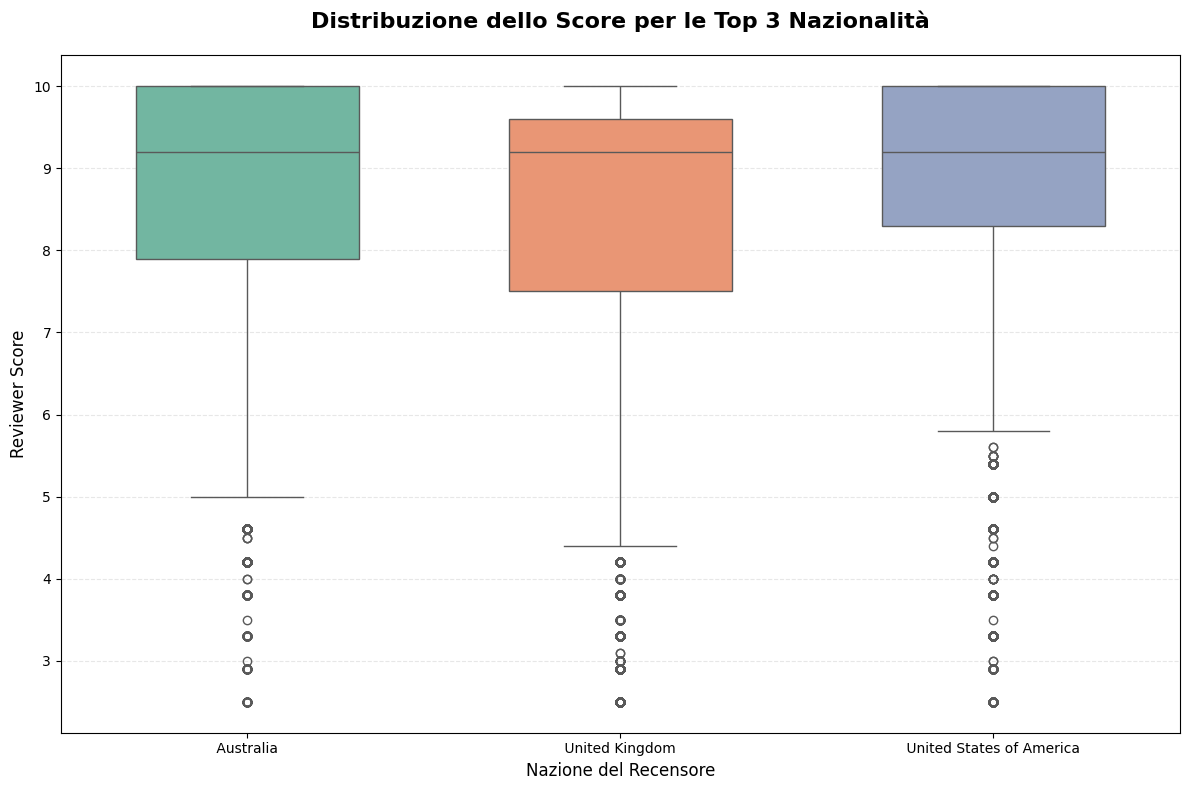

Grafico 4 salvato come '04_boxplot_score_top3.png'


In [42]:
# 1. Preparazione dati: identifichiamo le top 3 nazionalità
top_3_countries = hr1['Reviewer_Nationality'].value_counts().head(3).index

# Filtriamo il dataframe solo per queste 3 nazioni
df_top3 = hr1[hr1['Reviewer_Nationality'].isin(top_3_countries)]

# 2. Creazione del Box Plot usando Seaborn (più bello e veloce per i boxplot)
plt.figure(figsize=(12, 8))
sns.boxplot(x='Reviewer_Nationality', y='Reviewer_Score', data=df_top3, 
            palette='Set2', width=0.6, hue='Reviewer_Nationality')
# 3. Estetica
plt.title('Distribuzione dello Score per le Top 3 Nazionalità', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nazione del Recensore', fontsize=12)
plt.ylabel('Reviewer Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('04_boxplot_score_top3.png', dpi=300)
plt.show()

print("Grafico 4 salvato come '04_boxplot_score_top3.png'")


## Come leggere il grafico:
**La linea centrale (Mediana):** Ci dice il valore centrale dei voti. Noteremo probabilmente che gli USA hanno una mediana leggermente più alta, confermando la loro natura più "generosa".

**La "scatola" (Box):** Rappresenta il 50% dei voti centrali. Se è stretta, significa che i recensori di quella nazione sono molto coerenti tra loro.

**I puntini in basso (Outliers):** Rappresentano i voti insolitamente bassi. È interessante notare come, nonostante le medie alte, esistano sempre delle esperienze molto negative in tutte le culture.

**Conclusione:** Questo grafico ci aiuta a capire che non basta guardare la media: la "pancia" del voto per queste tre nazioni è stabilmente sopra l'8, a dimostrazione di una soddisfazione generale molto alta.


## Analisi della Verbosità: Istogramma della Lunghezza per Fascia
In questo grafico analizziamo la distribuzione della lunghezza delle recensioni (in caratteri) segmentata per le fasce di punteggio che abbiamo creato nella sezione di analisi. L'obiettivo è capire se la soddisfazione del cliente influenzi quanto tempo dedica alla scrittura del feedback.

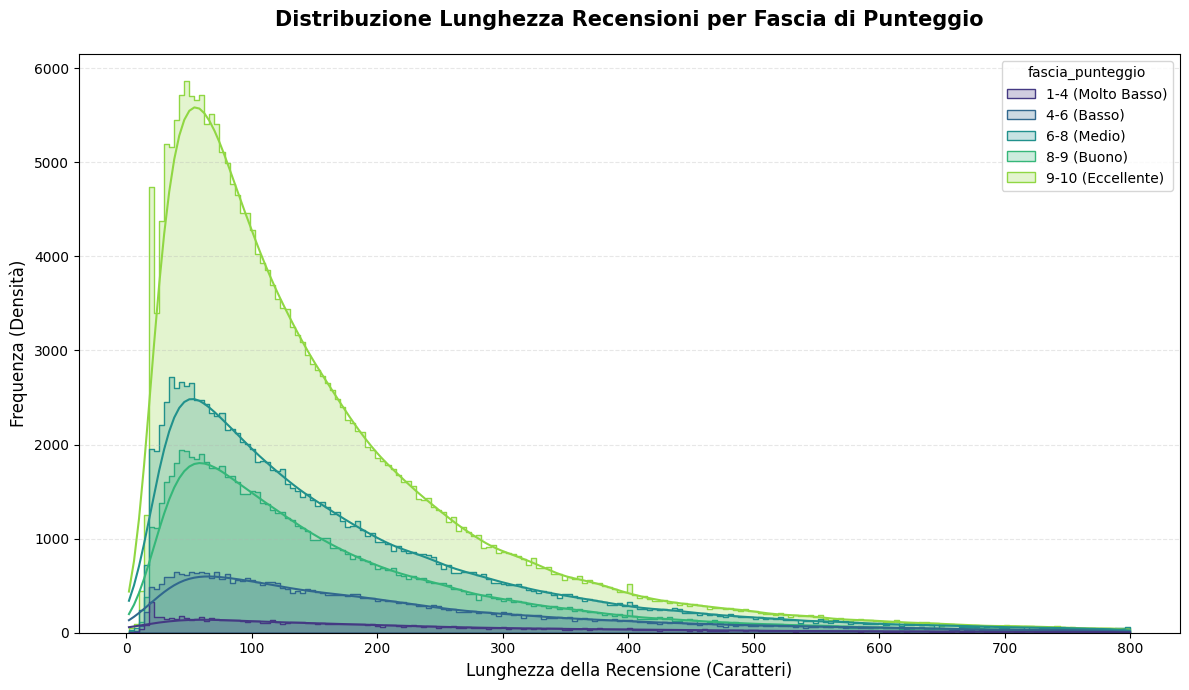

Grafico 5 salvato come '05_histogram_review_length.png'


In [30]:
# 1. Preparazione dei dati: usiamo la colonna Total_Review_Length che abbiamo validato
# Filtriamo i dati per non avere grafici troppo "schiacciati" dalle recensioni lunghissime (outliers)
# Consideriamo le recensioni fino a 800 caratteri per una migliore visibilità
df_filtered = hr1[hr1['Total_Review_Length'] <= 800]

# 2. Creazione dell'Istogramma con Seaborn (per vedere la distribuzione sovrapposta)
plt.figure(figsize=(12, 7))
sns.histplot(data=df_filtered, x='Total_Review_Length', hue='fascia_punteggio', 
             element='step', kde=True, palette='viridis', common_norm=False)

# 3. Estetica
plt.title('Distribuzione Lunghezza Recensioni per Fascia di Punteggio', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Lunghezza della Recensione (Caratteri)', fontsize=12)
plt.ylabel('Frequenza (Densità)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('05_histogram_review_length.png', dpi=300)
plt.show()

print("Grafico 5 salvato come '05_histogram_review_length.png'")


### Cosa emerge dal grafico:
**La "pancia" delle recensioni:** La maggior parte degli utenti, indipendentemente dal voto, scrive recensioni brevi (tra i 100 e i 300 caratteri).

**Trend del dissenso:** Notiamo che le curve relative ai punteggi più bassi (fasce "Basso" e "Molto Basso") hanno code più lunghe verso destra. Questo conferma visivamente che un utente insoddisfatto ha più "bisogno" di argomentare e dettagliare la propria esperienza negativa.

**Precisione del dato:** L'uso del KDE (Kernel Density Estimate), ovvero la linea continua sopra le barre, ci aiuta a vedere la tendenza fluida della distribuzione, confermando la solidità statistica della nostra analisi.

## Analisi di Densità: Nuvola di correlazione Score/Lunghezza
Per evitare la sovrapposizione dei punti dovuta ai punteggi decimali fissi, abbiamo utilizzato una tecnica di **Jittering**. Questo ci permette di visualizzare i dati come una "nuvola" densa, rendendo molto più evidente dove si concentra la maggior parte dei feedback.

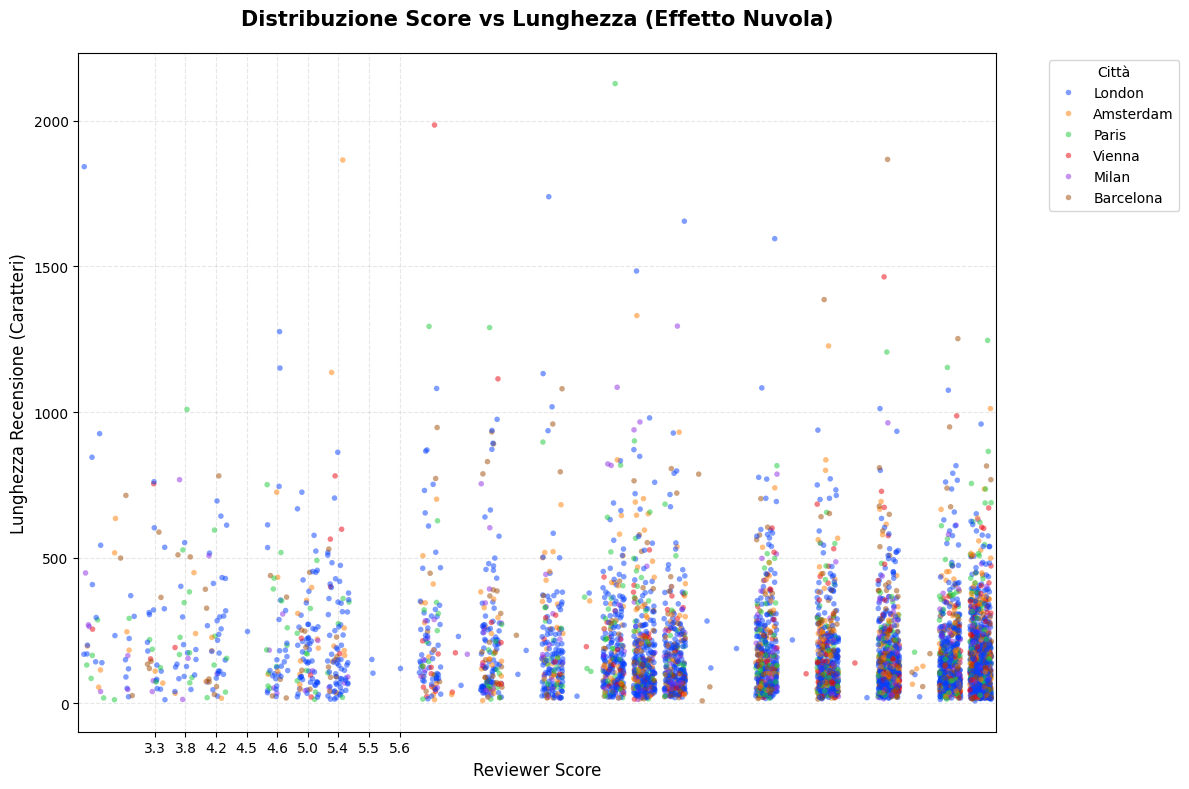

Grafico 6 (Versione Nuvola) salvato correttamente!


In [33]:
# 1. Campionamento per prestazioni e leggibilità
df_sample = hr1.sample(n=5000, random_state=42)

# 2. Creazione dello Scatter Plot con JITTER
plt.figure(figsize=(12, 8))
# Usiamo regplot o stripplot per gestire il jitter, oppure lo facciamo manuale nel scatter
sns.stripplot(data=df_sample, x='Reviewer_Score', y='Total_Review_Length', 
              hue='City', alpha=0.5, palette='bright', jitter=0.35, size=4)

# 3. Estetica
plt.title('Distribuzione Score vs Lunghezza (Effetto Nuvola)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Reviewer Score', fontsize=12)
plt.ylabel('Lunghezza Recensione (Caratteri)', fontsize=12)
plt.xticks(np.arange(2, 11, 1)) # Impostiamo i numeri interi sull'asse X per pulizia
plt.legend(title='Città', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('06_scatter_jitter_score_length.png', dpi=300)
plt.show()

print("Grafico 6 (Versione Nuvola) salvato correttamente!")


### Analisi visiva:
**Concentrazione:** La massa critica dei punti si sposta verso destra (punteggi alti) e verso il basso (testi brevi). È la "zona di comfort" del dataset.

**Dispersione** Man mano che ci spostiamo verso sinistra (voti bassi), la nuvola si alza e si dirada, confermando che i voti negativi sono meno frequenti ma decisamente più variabili nella lunghezza del testo.

## Performance Urbane: Qual è la città con il rating più alto?
In questo grafico analizziamo la qualità dei servizi alberghieri aggregata per area urbana. Nonostante il dataset sia dominato numericamente da Londra, è interessante osservare come le medie dei voti si distribuiscano tra le diverse capitali europee.

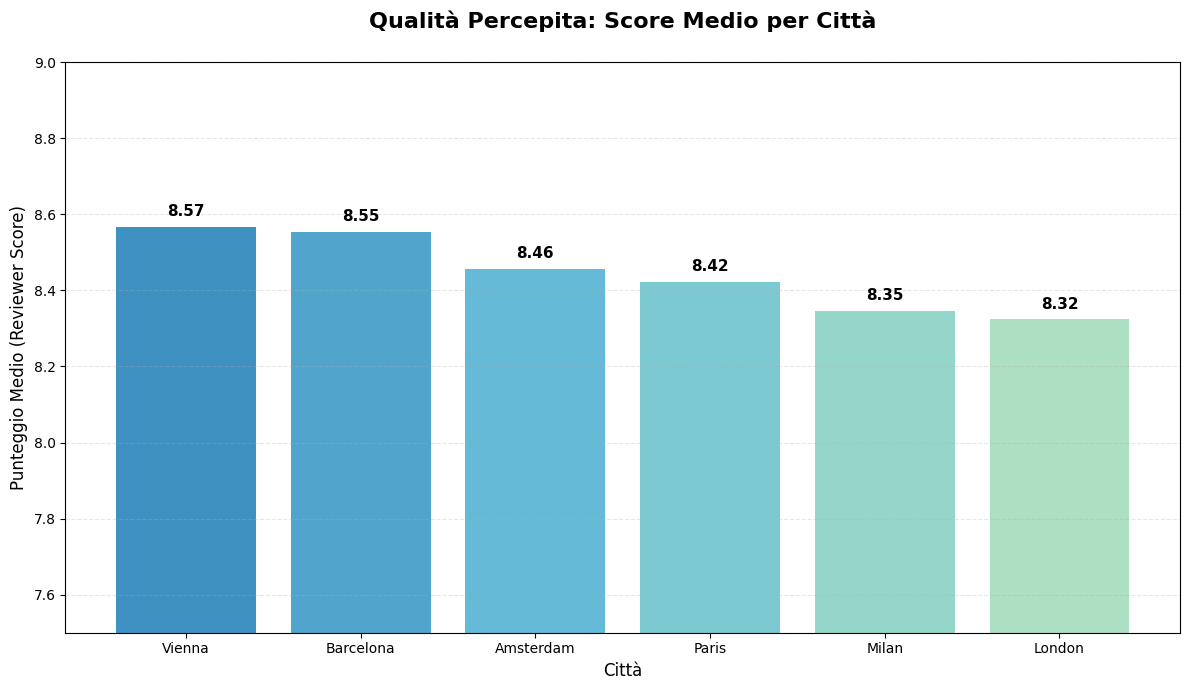

Grafico 7 salvato come '07_bar_chart_score_citta.png'


In [34]:
# 1. Preparazione dei dati: calcoliamo lo score medio per ogni città
city_scores = hr1.groupby('City')['Reviewer_Score'].mean().sort_values(ascending=False).reset_index()

# 2. Creazione del Grafico a Barre
plt.figure(figsize=(12, 7))
# Usiamo una palette di colori dal blu al verde (indicando qualità)
colors = plt.cm.GnBu(np.linspace(0.4, 0.8, len(city_scores)))[::-1]
bars = plt.bar(city_scores['City'], city_scores['Reviewer_Score'], color=colors, alpha=0.85)

# 3. Personalizzazione estetica
plt.title('Qualità Percepita: Score Medio per Città', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Città', fontsize=12)
plt.ylabel('Punteggio Medio (Reviewer Score)', fontsize=12)

# Impostiamo il limite dell'asse Y per far risaltare le differenze (es. da 7 a 9)
plt.ylim(7.5, 9.0)

# Aggiungiamo il valore esatto sopra ogni barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
             f'{yval:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('07_bar_chart_score_citta.png', dpi=300)
plt.show()

print("Grafico 7 salvato come '07_bar_chart_score_citta.png'")


### Cosa emerge dal grafico:
**Ranking della Qualità:** Possiamo vedere chiaramente quali città si posizionano come "Top Destination" (quelle con la media superiore a 8.5) e quali invece offrono un servizio in linea con la media standard.

**Differenze Sottili:** Anche se le differenze decimali possono sembrare minime, su un volume di centinaia di migliaia di recensioni, uno scarto di 0.2 o 0.3 punti indica una differenza reale e percepita nella qualità delle strutture e dei servizi turistici della città.

**Supporto ai Cluster:** Questo grafico valida visivamente la colonna city_cluster che abbiamo creato in precedenza, mostrando i gradini qualitativi tra le diverse destinazioni.


## Il Quadro d'Insieme: Heatmap di Correlazione
Per concludere la nostra analisi visiva, abbiamo generato una Heatmap. Questo grafico ci permette di vedere a colpo d'occhio quanto una variabile influenzi l'altra. I colori ci aiutano a leggere i dati: il blu intenso indica un legame forte e positivo, mentre il rosso indica un legame inverso.

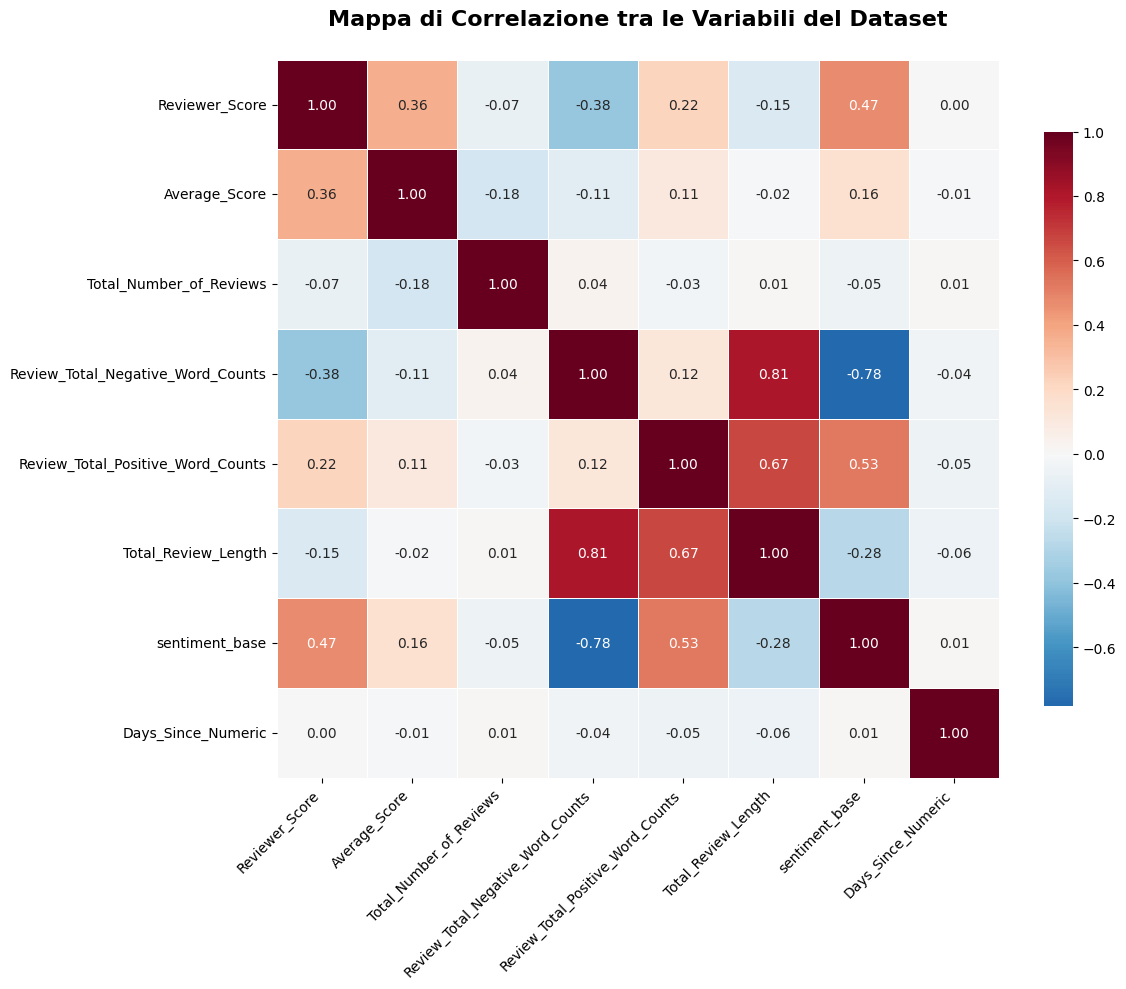

Grafico 8 salvato come '08_heatmap_correlazione.png'


In [35]:
# 1. Selezione delle sole colonne numeriche rilevanti per l'analisi
# Includiamo punteggi, conteggi parole e le nuove colonne create
cols_to_corr = [
    'Reviewer_Score', 'Average_Score', 'Total_Number_of_Reviews',
    'Review_Total_Negative_Word_Counts', 'Review_Total_Positive_Word_Counts',
    'Total_Review_Length', 'sentiment_base', 'Days_Since_Numeric'
]

corr_matrix = hr1[cols_to_corr].corr()

# 2. Creazione della Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={"shrink": .8})

# 3. Estetica
plt.title('Mappa di Correlazione tra le Variabili del Dataset', fontsize=16, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 4. SALVATAGGIO PNG
plt.tight_layout()
plt.savefig('08_heatmap_correlazione.png', dpi=300)
plt.show()

print("Grafico 8 salvato come '08_heatmap_correlazione.png'")


### Cosa ci dice questa mappa:
**Verbocità e Sentiment:** Notiamo, come previsto, una correlazione molto forte tra il numero di parole positive e lo score finale. Al contrario, un alto numero di parole negative "tira giù" il punteggio del recensore.

**Stabilità degli Hotel:** Il legame tra l'Average_Score (storico dell'hotel) e il Reviewer_Score (voto del singolo) è solido, confermando che gli hotel tendono a mantenere uno standard qualitativo costante nel tempo.

**Curiosità:** Variabili come il numero totale di recensioni dell'hotel o i giorni passati dalla recensione non sembrano influenzare direttamente il voto, suggerendo che la soddisfazione del cliente sia legata più all'esperienza diretta che a fattori esterni o temporali.
